# Variational Autoencoder (VAE)

Useful links: 
* Original paper http://arxiv.org/abs/1312.6114
* Helpful videos explaining the topic 
   * https://www.youtube.com/watch?v=P78QYjWh5sM     
   * http://videolectures.net/deeplearning2015_courville_autoencoder_extension/?q=aaron%20courville

### Download data

In [1]:
#!L
from yfile import download_from_yadisk
import os

TARGET_DIR = '.'
FILENAME = "celeba.zip"

if not os.path.exists(os.path.join(TARGET_DIR, FILENAME)):
    # we are going to download 1.4 gb file, downloading will take some time (8-10 minutes)
    download_from_yadisk(
        short_url='https://disk.yandex.ru/d/QErNx-MoC-2Y6Q',
        filename=FILENAME,
        target_dir=TARGET_DIR
    )

    # alternative way: 
    #from gfile import download_list
    #download_list(url=https://drive.google.com/file/d/1lwn2JMwWNGloGvyzKUOcewT8JqP1ICoW,
    #               filename=FILENAME, target_dir=TARGET_DIR)

filesize = os.path.getsize(os.path.join(TARGET_DIR, FILENAME))
GB = 2**30
assert filesize > 1 * GB, "{filesize} is too small, something wrong with downloading"

In [2]:
#!L:bash
!unzip celeba.zip

Archive:  celeba.zip
replace celeba/celeba/identity_CelebA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

^C


## Prepare the data

In [38]:
#!L
import math
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.utils import make_grid

device = torch.device("cuda")

In [4]:
#!L
class CropCelebA64:
    
    def __call__(self, pic):
        new_pic = pic.crop((15, 40, 178 - 15, 218 - 30))
        return new_pic

    def __repr__(self):
        return self.__class__.__name__ + '()'

In [5]:
#!L

# Note that for simplicity we reduce the number of channels to 1
# But if you want to be hardcore feel free to comment .Grayscale :)

train_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='train',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
    #download=True,   # in case of problems with downloading from gdrive above
)

validation_dataset = torchvision.datasets.CelebA(
    root='celeba',
    split='valid',
    transform=torchvision.transforms.Compose([
        CropCelebA64(),
        torchvision.transforms.Resize(64),
        torchvision.transforms.ToTensor(),
        
        torchvision.transforms.Grayscale()
    ]),
)

In [6]:
#!L
# Save first 10k images for evaluation
num_images = 10000
real_images_tensor = torch.stack([train_dataset[i][0] for i in range(num_images)], dim=0)
real_images = real_images_tensor.data.numpy().transpose([0, 2, 3, 1])
np.savez("real.npz", Pictures=real_images.reshape(num_images, 64 * 64 * 1))

In [17]:
#!L
BATCH_SIZE = 64

# you may find useful parameters `num_workers` and `pin_memory`
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, num_workers=4)

# Autoencoder

Why to use all this complicated formulaes and regularizations, what is the need for variational inference? To analyze the difference, let's first train just an autoencoder on the data:

In [18]:
#!L
dimZ = 100  # Considering face reconstruction task, which size of representation seems reasonable?

# Define the decoder and encoder as networks with one hidden fc-layer
# (that means you will have 2 fc layers in each net)
# Use ReLU for hidden layers' activations
# GlorotUniform initialization for W
# Zero initialization for biases
# It's also convenient to put sigmoid activation on output layer to get nice normalized pics


class Autoencoder(nn.Module):
    
    def __init__(self):
        super(Autoencoder, self).__init__()

        hidden_size = 1024

        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(64 * 64, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, hidden_size // 2),
            torch.nn.ReLU(),
        )
    
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(hidden_size // 2, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, 64 * 64),
            torch.nn.Sigmoid(),
        )

    def forward(self, x):

        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)

        latent_code = self.encoder(x_flat)
        reconstruction = self.decoder(latent_code).view(batch_size, 1, 64, 64)

        return reconstruction, latent_code

In [19]:
#!L
# Create MSE loss function
criterion = torch.nn.MSELoss()

autoencoder = Autoencoder().to(device)

# Use Adam optimizer
optimizer = optim.Adam(autoencoder.parameters())

In [51]:
import torchvision
from torchvision.utils import make_grid

import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback, EarlyStopping
from IPython.display import clear_output, display

device = torch.device("cuda")

In [45]:
class AutoencoderModule(pl.LightningModule):
    def __init__(self, model, criterion, lr=1e-3):
        super().__init__()
        self.autoencoder = model
        self.criterion = criterion
        self.lr = lr

    def forward(self, x):
        recon, _ = self.autoencoder(x)
        return recon

    def training_step(self, batch, batch_idx):
        images, _ = batch
        recon, _ = self.autoencoder(images)
        loss = self.criterion(recon, images)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.autoencoder.parameters(), lr=self.lr)

class LiveLossPlotter(Callback):
    def __init__(self, metric_name="train_loss", y_label="MSE loss", title="Autoencoder training loss"):
        """Display the history of any logged Lightning metric as training progresses."""
        self.metric_name = metric_name
        self.y_label = y_label
        self.title = title
        self.history = []
        self.fig, self.ax = plt.subplots(figsize=(6, 3))
        self.display_handle = display(self.fig, display_id=True)

    def on_train_epoch_end(self, trainer, pl_module):
        metric = trainer.callback_metrics.get(self.metric_name)
        if metric is None:
            return
        self.history.append(metric.item())
        self.ax.clear()
        self.ax.plot(self.history, marker='o')
        self.ax.set_xlabel("Epoch")
        self.ax.set_ylabel(self.y_label)
        self.ax.set_title(self.title)
        self.ax.grid(alpha=0.3)
        self.display_handle.update(self.fig)

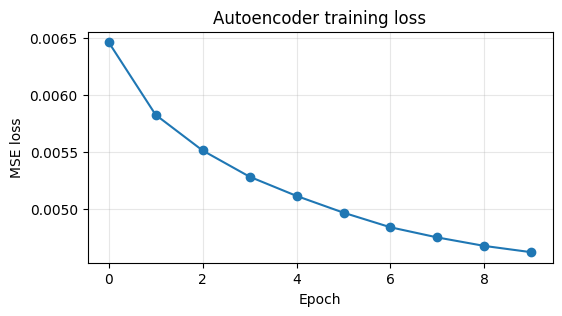

`Trainer.fit` stopped: `max_epochs=10` reached.


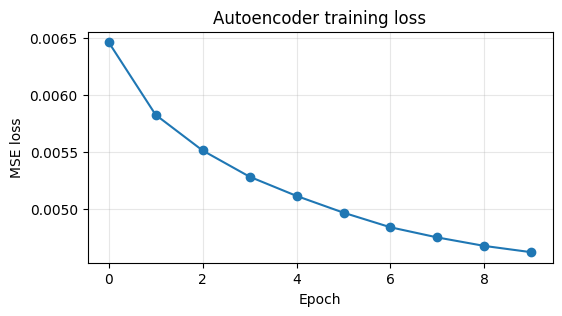

In [23]:
pl.seed_everything(42)
num_epochs = 10

autoencoder_module = AutoencoderModule(autoencoder, criterion, lr=1e-3)
loss_plotter = LiveLossPlotter()

trainer = pl.Trainer(
    max_epochs=num_epochs,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_checkpointing=False,
    logger=False,
    callbacks=[loss_plotter]
)

trainer.fit(autoencoder_module, train_loader)
train_losses = loss_plotter.train_losses

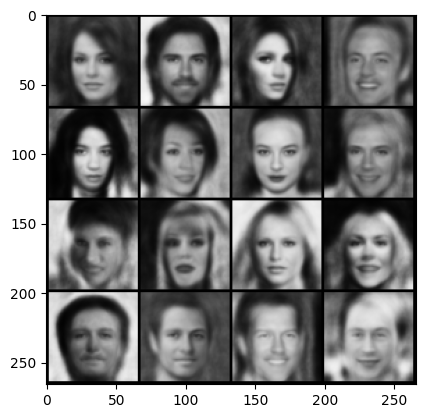

In [25]:
#!L
# Examine the reconstructions
from itertools import islice

autoencoder = autoencoder_module.autoencoder.eval().to(device)

images, _ = list(islice(val_loader, 1))[0]
reconstruction, latent_code = autoencoder(images.to(device))

reconstruction = reconstruction[:16].cpu()
plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

Reconstruction is not bad, right? 

# Sampling

Let's now sample several latent vectors and perform inference from $z$, reconstruct an image given some random $z$ representations.

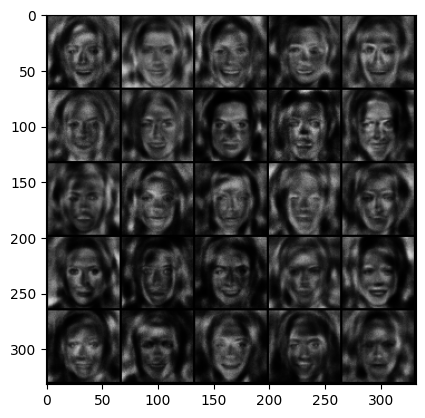

In [28]:
#!L
latent_dim = autoencoder.decoder[0].in_features 
z = torch.randn(25, latent_dim, device=device) * 0.5
reconstruction = autoencoder.decoder(z).clamp(0, 1).view(-1, 1, 64, 64)

plt.imshow(make_grid(reconstruction.cpu(), nrow=5).permute(1, 2, 0))

scary...

So, if we sample $z$ from normal, whould we eventually generate all possible faces? What do you think?

Answer: Yes, we would generate nearly all possible faces, because the domain of normal distribution is $\mathbb{R}^{dimZ}$. But because, our reconstruction is trained on some specific dataset, then the distribution of faces will be nearly identical (with difference to the optimisation and generalisations errors) to the distribution of the train dataset.

# Variational Autoencoder

Bayesian approach in deep learning considers everything in terms of distributions. Now our encoder generates not just a vector $z$ but posterior ditribution $q(z|x)$. In our case distribution $q$ is Gaussian distibution $N(\mu, \sigma)$ with parameters $\mu$, $\sigma$. Technically, the first difference is that you need to split bottleneck layer in two. One dense layer will generate vector $\mu$, and another will generate vector $\sigma$. Reparametrization trick should be implemented using the **gaussian_sampler** layer, that generates random vetor $\epsilon$ and returns $\mu+\sigma\epsilon \sim N(\mu, \sigma)$ .

Since our decoder is also a function that generates distribution, we need to do the same splitting for output layer. When testing the model we will look only on mean values, so one of the output will be actual autoencoder output.

In this homework we only ask for implementation of the simplest version of VAE - one $z$ sample per input. You can consider to sample several outputs from one input and average them.

In [30]:
#!L
# to compare with conventional AE, keep these hyperparameters
# or change them for the values that you used before
dimZ = 100

# define the network
# you can start from https://github.com/pytorch/examples/blob/master/vae/main.py
# or Theano-based examples here https://github.com/Lasagne/Recipes/blob/master/examples/variational_autoencoder/variational_autoencoder.py
# and here https://github.com/y0ast/Variational-Autoencoder/blob/master/VAE.py
# but remember that this is not your ground truth since the data is not MNIST

# here use Theano based implementation
# Lasage/Recipes sounds too cool to ignore
class VAE(nn.Module):
    
    def __init__(self, dim_z: int = dimZ, hidden_dim: int = 1024):
        super(VAE, self).__init__()
        self.dim_z = dim_z
        self.hidden_dim = hidden_dim

        self.encoder = nn.Sequential(
            nn.Linear(64 * 64, hidden_dim),
            nn.ReLU(inplace=True),
        )
        self.encoder_mu = nn.Linear(hidden_dim, dim_z)
        self.encoder_logsigma = nn.Linear(hidden_dim, dim_z)

        self.decoder = nn.Sequential(
            nn.Linear(dim_z, hidden_dim),
            nn.ReLU(inplace=True),
        )
        self.decoder_mu = nn.Linear(hidden_dim, 64 * 64)
        self.decoder_logsigma = nn.Linear(hidden_dim, 64 * 64)

        self._init_weights()

    def _init_weights(self):
        for layer in [self.encoder[0], self.encoder_mu, self.encoder_logsigma,
                      self.decoder[0], self.decoder_mu, self.decoder_logsigma]:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def gaussian_sampler(self, mu, logsigma):
        noise = torch.randn_like(mu)
        return noise * logsigma.exp() + mu

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.reshape(batch_size, -1)

        h = self.encoder(x_flat)
        latent_mu = self.encoder_mu(h)
        latent_logsigma = self.encoder_logsigma(h).clamp(min=-8.0, max=8.0)

        z = self.gaussian_sampler(latent_mu, latent_logsigma)

        h_dec = self.decoder(z)
        reconstruction_mu = torch.sigmoid(self.decoder_mu(h_dec)).reshape(batch_size, 1, 64, 64)
        reconstruction_logsigma = self.decoder_logsigma(h_dec).clamp(min=-4.5, max=1.5).reshape(batch_size, 1, 64, 64)

        return reconstruction_mu, reconstruction_logsigma, latent_mu, latent_logsigma

And the last, but not least! Place in the code where the most of the formulaes goes to - optimization objective. The objective for VAE has it's own name - variational lowerbound. And as for any lowerbound our intention is to maximize it. Here it is (for one sample $z$ per input $x$):

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z) \to max$$

Your next task is to implement two functions that compute KL-divergence and the second term - log-likelihood of an output. Here is some necessary math for your convenience:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$
$$\log p_{\theta}(x|z) = \sum_{i=1}^{dimX}\log p_{\theta}(x_i|z)=\sum_{i=1}^{dimX} \log \Big( \frac{1}{\sigma_i\sqrt{2\pi}}e^{-\frac{(\mu_i-x)^2}{2\sigma_i^2}} \Big)=...$$

Don't forget in the code that you are using $\log\sigma$ as variable. Explain, why not $\sigma$?

In [32]:
#!L

def KL_divergence(mu, logsigma):
    mu = mu.reshape(mu.size(0), -1)
    logsigma = logsigma.reshape(logsigma.size(0), -1)
    kl = -0.5 * (1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma))
    return kl.sum(dim=1).mean()


def log_likelihood(x, mu, logsigma):
    x_flat = x.reshape(x.size(0), -1)
    mu_flat = mu.reshape(mu.size(0), -1)
    logsigma_flat = logsigma.reshape(logsigma.size(0), -1)
    var = torch.exp(2 * logsigma_flat) + 1e-6
    log_prob = -0.5 * math.log(2 * math.pi) - logsigma_flat - 0.5 * (x_flat - mu_flat).pow(2) / var
    return log_prob.sum(dim=1).mean()


def loss_vae(x, mu_gen, logsigma_gen, mu_z, logsigma_z):
    log_pxz = log_likelihood(x, mu_gen, logsigma_gen)
    kl = KL_divergence(mu_z, logsigma_z)
    return kl - log_pxz

And train the model:

In [52]:
class VAEModule(pl.LightningModule):
    def __init__(self, model, lr=5e-4):
        super().__init__()
        self.model = model
        self.lr = lr
        self.save_hyperparameters(ignore=["model"])

    def forward(self, x):
        recon_mu, _, _, _ = self.model(x)
        return recon_mu

    def training_step(self, batch, batch_idx):
        images, _ = batch
        recon_mu, recon_logsigma, latent_mu, latent_logsigma = self.model(images)
        loss = loss_vae(images, recon_mu, recon_logsigma, latent_mu, latent_logsigma)
        recon_mse = torch.nn.functional.mse_loss(recon_mu, images)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_recon_mse", recon_mse, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, _ = batch
        recon_mu, recon_logsigma, latent_mu, latent_logsigma = self.model(images)
        val_loss = loss_vae(images, recon_mu, recon_logsigma, latent_mu, latent_logsigma)
        val_recon_mse = torch.nn.functional.mse_loss(recon_mu, images)
        self.log("val_loss", val_loss, prog_bar=True)
        self.log("val_recon_mse", val_recon_mse, prog_bar=False)
        return val_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.model.parameters(), lr=self.lr)

In [53]:
class VAEReconCallback(Callback):
    def __init__(self, val_loader, max_images=16):
        self.val_loader = val_loader
        self.max_images = max_images

    def on_validation_epoch_end(self, trainer, pl_module):
        images, _ = next(iter(self.val_loader))
        images = images.to(pl_module.device)
        with torch.no_grad():
            recon, _, _, _ = pl_module.model(images)
        grid = make_grid(recon[: self.max_images].cpu(), nrow=int(math.sqrt(self.max_images)))
        plt.figure(figsize=(4, 4))
        plt.title(f"Epoch {trainer.current_epoch:02d} reconstructions")
        plt.axis("off")
        plt.imshow(grid.permute(1, 2, 0).squeeze(-1), cmap="gray")
        clear_output(wait=True)
        display(plt.gcf())
        plt.close()

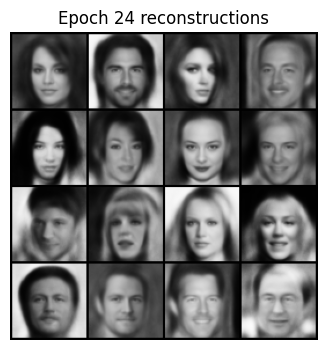

`Trainer.fit` stopped: `max_epochs=25` reached.


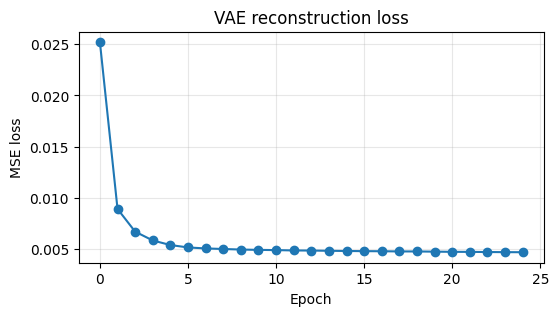

In [54]:
pl.seed_everything(42)
vae = VAE().to(device)
vae_module = VAEModule(vae, lr=5e-4)
loss_plotter = LiveLossPlotter(
    metric_name="train_recon_mse",
    y_label="MSE loss",
    title="VAE reconstruction loss"
)
recon_callback = VAEReconCallback(val_loader)
early_stopping = EarlyStopping(monitor="val_loss", mode="min", patience=5, min_delta=1e-4)
trainer = pl.Trainer(
    max_epochs=25,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_checkpointing=False,
    logger=False,
    callbacks=[loss_plotter, recon_callback, early_stopping],
)

trainer.fit(vae_module, train_loader, val_loader)
vae = vae_module.model.eval().to(device)

In [ ]:
#!L
# train your variational autoencoder
# visualize progress in reconstruction and loss decay

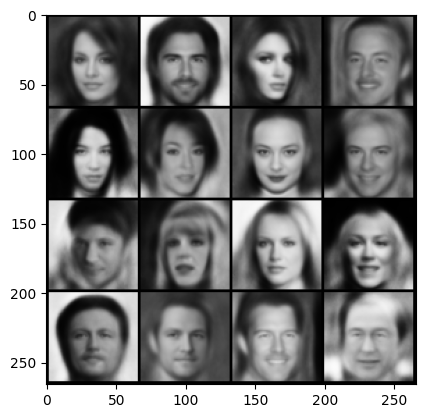

In [55]:
#!L
images, _ = list(islice(val_loader, 1))[0]
mu_gen, _, _, _ = vae(images.to(device))
reconstruction = mu_gen[:16].cpu().clamp(0, 1)

plt.imshow(make_grid(reconstruction, nrow=4).permute(1, 2, 0))

And finally sample from VAE.

In [ ]:
#!L
# TODO
# Sample some images from the learned distribution
# 1) Sample z ~ N(0,1)
# 2) Sample from N(decoder_mu(z), decoder_sigma(z))

(np.float64(-0.5), np.float64(331.5), np.float64(331.5), np.float64(-0.5))

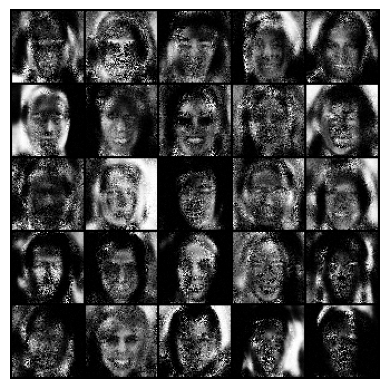

In [56]:
with torch.no_grad():
    num_samples = 25
    # 1) Sample z ~ N(0,1)
    z = torch.randn(num_samples, vae.dim_z, device=device)
    h_dec = vae.decoder(z)
    mu = torch.sigmoid(vae.decoder_mu(h_dec)).view(num_samples, 1, 64, 64)
    logsigma = vae.decoder_logsigma(h_dec).clamp(min=-4.5, max=1.5).view(num_samples, 1, 64, 64)
    # 2) Sample from N(decoder_mu(z), decoder_sigma(z))
    samples = torch.randn_like(mu) * logsigma.exp() + mu 
    samples = samples.clamp(0, 1)

plt.imshow(make_grid(samples.cpu(), nrow=5).permute(1, 2, 0).squeeze(-1), cmap="gray")
plt.axis("off")

# Congrats! and Bonus

If you managed to tune your autoencoders to converge and learn something about the world, now it's time to make fun out of it. As you may have noticed, there are face attributes in dataset. We're interesting in "Smiling" column (index 31 of the attribute vector), but feel free to try others as well! Here is the first task:

1) Extract the "Smilling" attribute and create a two sets of images: 10 smiling faces and 10 non-smiling ones.

2) Compute latent representations for each image in "smiling" set and average those latent vectors. Do the same for "non-smiling" set. You have found **"vector representation"** of the "smile" and "no smile" attribute.

3) Compute the difference: "smile" vector minus "non-smile" vector.

3) Now check if **"feature arithmetics"** works. Sample a face without smile, encode it and add the diff from p. 3. Check if it works with both AE and VAE. 

(np.float64(-0.5), np.float64(199.5), np.float64(67.5), np.float64(-0.5))

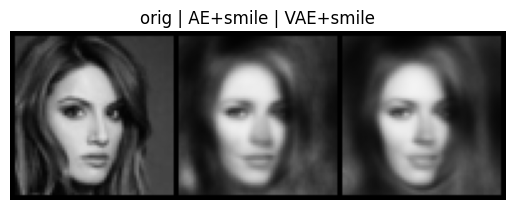

In [58]:
attr_idx = 31

def grab(positive=True, k=10):
    bag = []
    for img, attr in validation_dataset:
        if (attr[attr_idx].item() > 0) == positive:
            bag.append(img)
            if len(bag) == k:
                break
    return torch.stack(bag).to(device)

smile, nosmile = grab(True), grab(False)
target = nosmile[:1]

with torch.no_grad():
    def ae_latent(x):
        _, latent = autoencoder(x)
        return latent

    smile_latent_ae = ae_latent(smile).mean(dim=0, keepdim=True)
    nosmile_latent_ae = ae_latent(nosmile).mean(dim=0, keepdim=True)
    smile_vector_ae = smile_latent_ae - nosmile_latent_ae
    target_latent_ae = ae_latent(target)
    decoded_ae = autoencoder.decoder(target_latent_ae + smile_vector_ae)
    ae_shift = decoded_ae.view(-1, 1, 64, 64).clamp(0, 1)

    def vae_latent(x):
        flat = x.view(x.size(0), -1)
        hidden = vae.encoder(flat)
        return vae.encoder_mu(hidden)

    smile_latent_vae = vae_latent(smile).mean(dim=0, keepdim=True)
    nosmile_latent_vae = vae_latent(nosmile).mean(dim=0, keepdim=True)
    smile_vector_vae = smile_latent_vae - nosmile_latent_vae
    target_latent_vae = vae_latent(target)
    shifted_latent_vae = target_latent_vae + smile_vector_vae
    hidden_decoded = vae.decoder(shifted_latent_vae)
    mu_decoded = torch.sigmoid(vae.decoder_mu(hidden_decoded))
    vae_shift = mu_decoded.view(-1, 1, 64, 64)

grid = torch.cat([target.cpu(), ae_shift.cpu(), vae_shift.cpu()])
plt.imshow(make_grid(grid, nrow=3).permute(1, 2, 0).squeeze(-1), cmap="gray")
plt.title("orig | AE+smile | VAE+smile")
plt.axis("off")

In [ ]:
#!L
with torch.no_grad():
    # pick 10 random non-smiling faces and apply both smile shifts
    perm = torch.randperm(nosmile.size(0), device=device)[:10]
    samples = nosmile[perm]
    
    ae_latents = ae_latent(samples)
    ae_shifted = autoencoder.decoder(ae_latents + smile_vector_ae).view(-1, 1, 64, 64).clamp(0, 1)
    
    vae_latents = vae_latent(samples)
    hidden = vae.decoder(vae_latents + smile_vector_vae)
    vae_shifted = torch.sigmoid(vae.decoder_mu(hidden)).view(-1, 1, 64, 64)
    
    def plot_grid(imgs, title, nrow=5):
        grid = make_grid(imgs.cpu(), nrow=nrow)
        plt.figure(figsize=(6, 4))
        plt.imshow(grid.permute(1, 2, 0).squeeze(-1), cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()
    
    plot_grid(samples, "Original non-smiling faces (random 10)")
    plot_grid(ae_shifted, "AE + smile vector (10 examples)")
    plot_grid(vae_shifted, "VAE + smile vector (10 examples)")

<img src="linear.png" alt="linear">